In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip '/content/lllll.zip'

Archive:  /content/lllll.zip
  inflating: Aquarium Combined/README.dataset.txt  
  inflating: Aquarium Combined/README.roboflow.txt  
  inflating: Aquarium Combined/test/IMG_2289_jpeg_jpg.rf.fe2a7a149e7b11f2313f5a7b30386e85.jpg  
  inflating: Aquarium Combined/test/IMG_2301_jpeg_jpg.rf.2c19ae5efbd1f8611b5578125f001695.jpg  
  inflating: Aquarium Combined/test/IMG_2319_jpeg_jpg.rf.6e20bf97d17b74a8948aa48776c40454.jpg  
  inflating: Aquarium Combined/test/IMG_2347_jpeg_jpg.rf.7c71ac4b9301eb358cd4a832844dedcb.jpg  
  inflating: Aquarium Combined/test/IMG_2354_jpeg_jpg.rf.396e872c7fb0a95e911806986995ee7a.jpg  
  inflating: Aquarium Combined/test/IMG_2371_jpeg_jpg.rf.54505f60b6706da151c164188c305849.jpg  
  inflating: Aquarium Combined/test/IMG_2379_jpeg_jpg.rf.7dc3160c937072d26d4624c6c48e904d.jpg  
  inflating: Aquarium Combined/test/IMG_2380_jpeg_jpg.rf.a23809682eb1466c1136ca0f55de8fb5.jpg  
  inflating: Aquarium Combined/test/IMG_2387_jpeg_jpg.rf.09b38bacfab0922a3a6b66480f01b719.jpg  
  

In [ ]:
import numpy as np
import pandas as pd
import os
import torch
import torchvision
from torchvision import datasets, models
from torchvision.transforms import functional as FT
from torchvision import transforms as T
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, sampler, random_split, Dataset
import copy
import math
from PIL import Image
import cv2
import albumentations as A  # our data augmentation library

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from collections import defaultdict, deque
import datetime
import time
from tqdm import tqdm
from torchvision.utils import draw_bounding_boxes


In [ ]:
!pip install pycocotools
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


In [ ]:
from albumentations.pytorch import ToTensorV2

In [ ]:
# We use albumentations as our data augmentation library due to its capability to deal with bounding boxes in multiple formats
def get_transforms(train=False):
    if train:
        transform = A.Compose([
            A.Resize(600, 600), # our input size can be 600px
            A.HorizontalFlip(p=0.3),
            A.VerticalFlip(p=0.3),
            A.RandomBrightnessContrast(p=0.1),
            A.ColorJitter(p=0.1),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco'))
    else:
        transform = A.Compose([
            A.Resize(600, 600), # our input size can be 600px
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco'))
    return transform

In [ ]:
class AquariumDetection(datasets.VisionDataset):
    def __init__(self, root, split='train', transform=None, target_transform=None, transforms=None):
        # the 3 transform parameters are reuqired for datasets.VisionDataset
        super().__init__(root, transforms, transform, target_transform)
        self.split = split #train, valid, test
        self.coco = COCO(os.path.join(root, split, "_annotations.coco.json")) # annotatiosn stored here
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.ids = [id for id in self.ids if (len(self._load_target(id)) > 0)]

    def _load_image(self, id: int):
        path = self.coco.loadImgs(id)[0]['file_name']
        image = cv2.imread(os.path.join(self.root, self.split, path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image
    def _load_target(self, id):
        return self.coco.loadAnns(self.coco.getAnnIds(id))

    def __getitem__(self, index):
        id = self.ids[index]
        image = self._load_image(id)
        target = self._load_target(id)
        target = copy.deepcopy(self._load_target(id))

        boxes = [t['bbox'] + [t['category_id']] for t in target] # required annotation format for albumentations
        if self.transforms is not None:
            transformed = self.transforms(image=image, bboxes=boxes)

        image = transformed['image']
        boxes = transformed['bboxes']

        new_boxes = [] # convert from xywh to xyxy
        for box in boxes:
            xmin = box[0]
            xmax = xmin + box[2]
            ymin = box[1]
            ymax = ymin + box[3]
            new_boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.tensor(new_boxes, dtype=torch.float32)

        targ = {} # here is our transformed target
        targ['boxes'] = boxes
        targ['labels'] = torch.tensor([t['category_id'] for t in target], dtype=torch.int64)
        targ['image_id'] = torch.tensor([t['image_id'] for t in target])
        targ['area'] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) # we have a different area
        targ['iscrowd'] = torch.tensor([t['iscrowd'] for t in target], dtype=torch.int64)
        return image.div(255), targ # scale images
    def __len__(self):
        return len(self.ids)

In [ ]:
dataset_path = "/content/Aquarium Combined"

In [ ]:
#load classes
coco = COCO(os.path.join(dataset_path, "train", "_annotations.coco.json"))
categories = coco.cats
n_classes = len(categories.keys())
categories

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


{0: {'id': 0, 'name': 'creatures', 'supercategory': 'none'},
 1: {'id': 1, 'name': 'fish', 'supercategory': 'creatures'},
 2: {'id': 2, 'name': 'jellyfish', 'supercategory': 'creatures'},
 3: {'id': 3, 'name': 'penguin', 'supercategory': 'creatures'},
 4: {'id': 4, 'name': 'puffin', 'supercategory': 'creatures'},
 5: {'id': 5, 'name': 'shark', 'supercategory': 'creatures'},
 6: {'id': 6, 'name': 'starfish', 'supercategory': 'creatures'},
 7: {'id': 7, 'name': 'stingray', 'supercategory': 'creatures'}}

In [ ]:
classes = [i[1]['name'] for i in categories.items()]
classes

['creatures',
 'fish',
 'jellyfish',
 'penguin',
 'puffin',
 'shark',
 'starfish',
 'stingray']

In [ ]:
# Create train and validation datasets
train_dataset = AquariumDetection(root=dataset_path, split='train', transforms=get_transforms(True))
val_dataset = AquariumDetection(root=dataset_path, split='valid', transforms=get_transforms(False))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [ ]:
# DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=4, collate_fn=lambda x: tuple(zip(*x)))

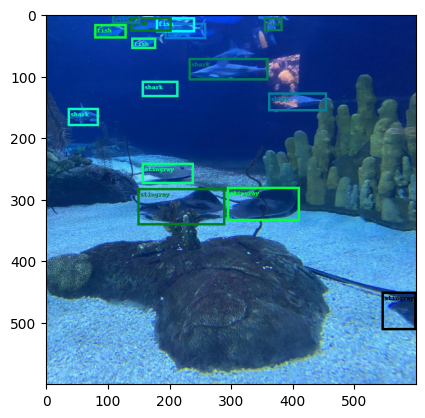

In [ ]:
#This is a sample image and its bounding boxes, this code does not get the model's output
sample = train_dataset[4]
img_int = torch.tensor(sample[0] * 255, dtype=torch.uint8)
plt.imshow(draw_bounding_boxes(
    img_int, sample[1]['boxes'], [classes[i] for i in sample[1]['labels']], width=4
).permute(1, 2, 0))

In [ ]:
len(train_dataset)

447

Model
Our model is FasterRCNN with a backbone of MobileNetV3-Large. We need to change the output layers because we have just 7 classes but this model was trained on 90 classes.


In [ ]:
model = models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, n_classes)

In [ ]:
#This is our collating function for the train dataloader, it allows us to create batches of data that can be easily pass into the model
def collate_fn(batch):
    return tuple(zip(*batch))


In [ ]:
#This blocks ensures that the model can take in the data and that it will not crash during training
images,targets = next(iter(train_loader))
images = list(image for image in images)
targets = [{k:v for k, v in t.items()} for t in targets]
output = model(images, targets) # just make sure this runs without error

In [ ]:
device = torch.device("cuda")

In [ ]:
# Optimizer and Learning Rate Scheduler

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [ ]:
import sys
def train_one_epoch(model, optimizer, loader, device, epoch):
    model.train()

    print(f"Epoch {epoch}")

    # Define warmup parameters
    warmup_factor = 1.0 / 1000
    warmup_iters = min(1000, len(loader) - 1)

    lr_scheduler = optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=warmup_factor,
        total_iters=warmup_iters
    )

    all_losses = []
    all_losses_dict = []

    for images, targets in tqdm(loader):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        all_losses.append(losses.item())
        all_losses_dict.append({k: v.item() for k, v in loss_dict.items()})

        lr_scheduler.step()

    mean_loss = np.mean(all_losses)
    mean_losses_dict = {k: np.mean([d[k] for d in all_losses_dict]) for k in all_losses_dict[0]}

    print(f"Epoch {epoch}, lr: {optimizer.param_groups[0]['lr']:.6f}, loss: {mean_loss:.6f}")
    for k, v in mean_losses_dict.items():
        print(f"{k}: {v:.6f}")

    return mean_loss, mean_losses_dict

In [ ]:
def evaluate_model(model, loader, device):
    model.eval()
    coco_gt = loader.dataset.coco
    coco_pred = []

    with torch.no_grad():
        for images, targets in tqdm(loader):
            images = list(image.to(device) for image in images)
            outputs = model(images)

            for target, output in zip(targets, outputs):
                # Diagnostic prints
                print("Image ID type:", type(target["image_id"]))
                print("Image ID shape:", target["image_id"].shape if isinstance(target["image_id"], torch.Tensor) else "Not a tensor")
                print("Image ID content:", target["image_id"])

                # Handle image_id based on its type and shape
                if isinstance(target["image_id"], torch.Tensor):
                    if target["image_id"].numel() == 1:
                        image_id = target["image_id"].item()
                    else:
                        # If it's a tensor with multiple elements, use the first one
                        image_id = target["image_id"][0].item()
                else:
                    # If it's not a tensor, use it as is (assuming it's a scalar)
                    image_id = target["image_id"]

                boxes = output["boxes"].cpu().numpy()
                scores = output["scores"].cpu().numpy()
                labels = output["labels"].cpu().numpy()

                boxes[:, 2:] -= boxes[:, :2]  # Convert boxes to COCO format (x_min, y_min, width, height)

                for box, score, label in zip(boxes, scores, labels):
                    coco_pred.append({
                        "image_id": int(image_id),  # Ensure image_id is an integer
                        "category_id": int(label),  # Ensure label is an integer
                        "bbox": box.tolist(),
                        "score": float(score)
                    })

    coco_dt = COCO.loadRes(coco_gt, coco_pred)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # Return the evaluation results
    return coco_eval.stats

In [ ]:
num_epochs = 10
for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, train_loader, device, epoch)
    lr_scheduler.step()  # Adjust the learning rate
    evaluate_model(model, val_loader, device)  # Evaluate after each epoch

Epoch 0


100%|██████████| 112/112 [00:21<00:00,  5.10it/s]


Epoch 0, lr: 0.005000, loss: 0.650815
loss_classifier: 0.256600
loss_box_reg: 0.335227
loss_objectness: 0.037402
loss_rpn_box_reg: 0.021585


  6%|▋         | 2/32 [00:01<00:15,  2.00it/s]

Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([1])
Image ID content: tensor([0])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([4])
Image ID content: tensor([1, 1, 1, 1])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([1])
Image ID content: tensor([2])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([1])
Image ID content: tensor([3])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([8])
Image ID content: tensor([4, 4, 4, 4, 4, 4, 4, 4])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([2])
Image ID content: tensor([5, 5])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([2])
Image ID content: tensor([6, 6])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([6])
Image ID content: tensor([7, 7, 7, 7, 7, 7])


...

Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([37])
Image ID content: tensor([112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112,
        112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112,
        112, 112, 112, 112, 112, 112, 112, 112, 112])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([13])
Image ID content: tensor([113, 113, 113, 113, 113, 113, 113, 113, 113, 113, 113, 113, 113])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([1])
Image ID content: tensor([114])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([5])
Image ID content: tensor([115, 115, 115, 115, 115])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([9])
Image ID content: tensor([116, 116, 116, 116, 116, 116, 116, 116, 116])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([20])
Image ID content: tensor([117, 117, 117, 117, 117, 117, 117, 117, 117, 117, 117, 117, 117, 117,
     

100%|██████████| 32/32 [00:04<00:00,  9.77it/s]

Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([6])
Image ID content: tensor([120, 120, 120, 120, 120, 120])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([4])
Image ID content: tensor([121, 121, 121, 121])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([1])
Image ID content: tensor([122])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([5])
Image ID content: tensor([123, 123, 123, 123, 123])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([28])
Image ID content: tensor([124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124,
        124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([11])
Image ID content: tensor([125, 125, 125, 125, 125, 125, 125, 125, 125, 125, 125])
Image ID type: <class 'torch.Tensor'>
Image ID shape: torch.Size([6])
Image ID content: tensor([126, 126, 126, 126, 126, 126])


100%|██████████| 32/32 [00:04<00:00,  7.40it/s]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.68s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.003
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [ ]:

model.eval()
# Clear CUDA memory after training
torch.cuda.empty_cache()

In [ ]:
test_dataset = AquariumDetection(root=dataset_path, split="test", transforms=get_transforms(False))


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [ ]:
img, _ = test_dataset[16]
img_int = torch.tensor(img*255, dtype=torch.uint8)
with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

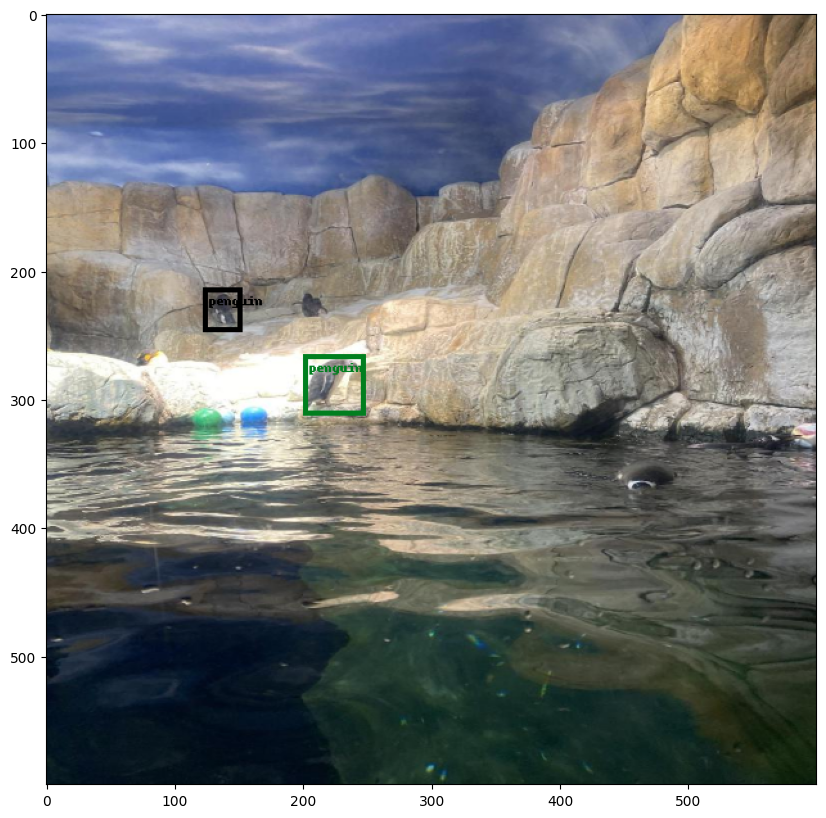

In [ ]:
fig = plt.figure(figsize=(14, 10))
plt.imshow(draw_bounding_boxes(img_int,
    pred['boxes'][pred['scores'] > 0.8],
    [classes[i] for i in pred['labels'][pred['scores'] > 0.8].tolist()], width=4
).permute(1, 2, 0))

In [ ]:
img, _ = test_dataset[11]
img_int = torch.tensor(img*255, dtype=torch.uint8)
with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

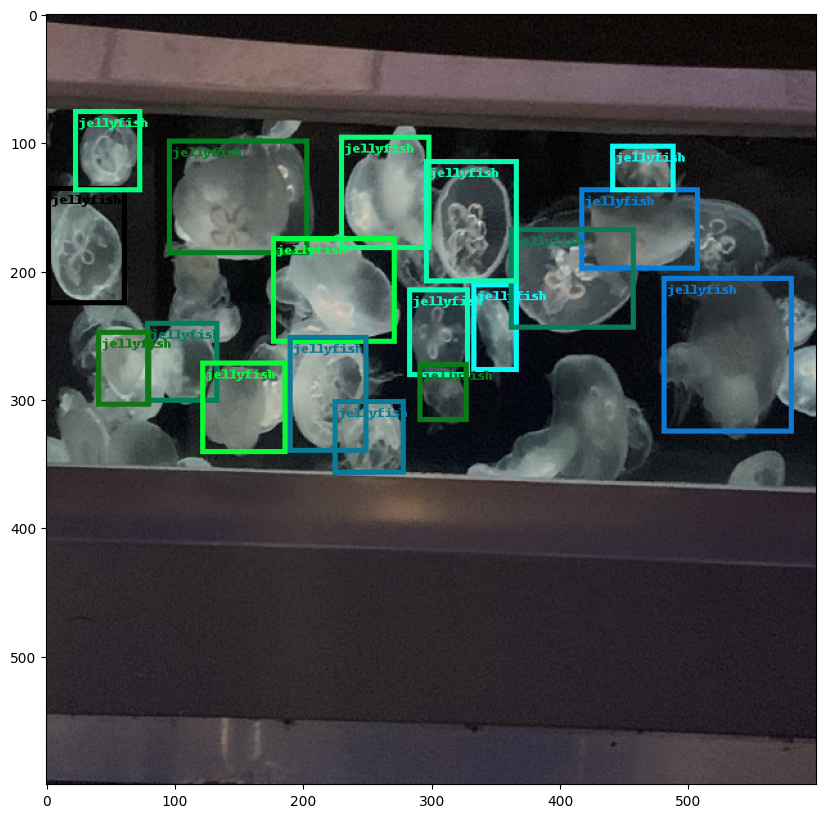

In [ ]:
fig = plt.figure(figsize=(14, 10))
plt.imshow(draw_bounding_boxes(img_int,
    pred['boxes'][pred['scores'] > 0.8],
    [classes[i] for i in pred['labels'][pred['scores'] > 0.8].tolist()], width=4
).permute(1, 2, 0))

In [ ]:
img, _ = test_dataset[7]
img_int = torch.tensor(img*255, dtype=torch.uint8)
with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

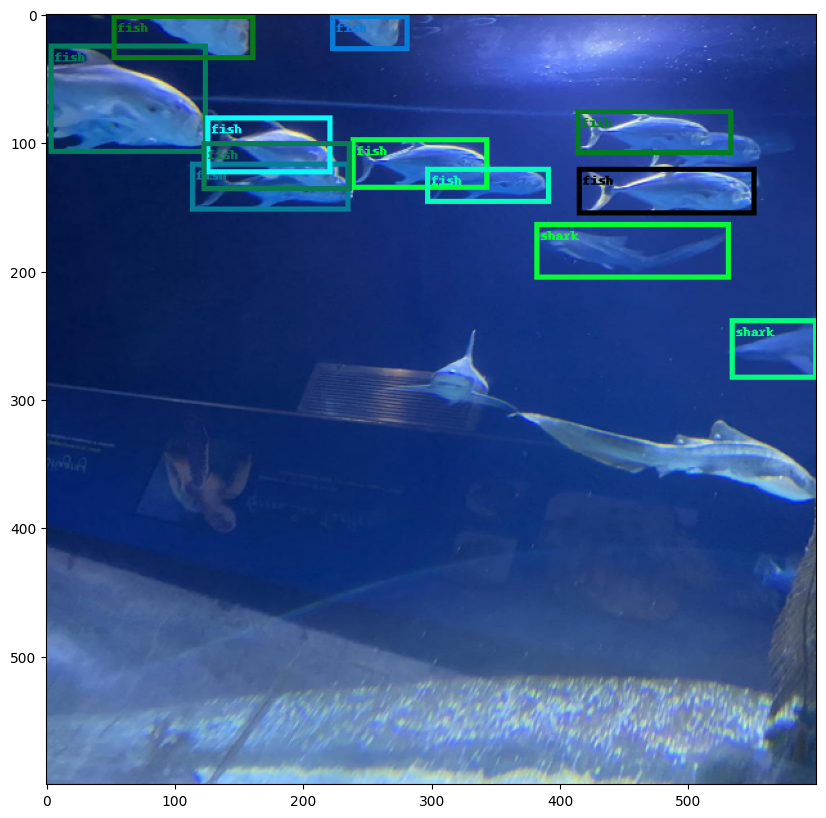

In [ ]:
fig = plt.figure(figsize=(14, 10))
plt.imshow(draw_bounding_boxes(img_int,
    pred['boxes'][pred['scores'] > 0.8],
    [classes[i] for i in pred['labels'][pred['scores'] > 0.8].tolist()], width=4
).permute(1, 2, 0))